<a href="https://colab.research.google.com/github/annabashlakova/ECON3916-Statistical-Machine-Learning/blob/main/Econ_3916_Assignment_2_Audit_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Step 1.1

normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate((normal_traffic, spike_traffic))

print(f"Total Requests: {len(latency_logs)}")
print(f"Mean Latency: {np.mean(latency_logs):.2f}ms")
print(f"Median Latency: {np.median(latency_logs):.2f}ms")

Total Requests: 1000
Mean Latency: 91.72ms
Median Latency: 35.00ms


In [7]:
# Step 1.2

def calculate_mad(data):
  # 1. Calc the median
  median = np.median(data)
  # 2. Calc abs deviation
  abs_deviation = np.abs(data - median)
  # 3. Return the Median of those deviations
  return np.median(abs_deviation)

# Compare SD vs MAD
sd = np.std(latency_logs)
mad = calculate_mad(latency_logs)

print(f"Standard Deviation: {sd:.2f}ms")
print(f"Median Absolute Deviation: {mad:.2f}ms")

Standard Deviation: 440.02ms
Median Absolute Deviation: 8.00ms


Analysis: The SD and MAD have a very large gap due to the 20 spike requests which the SD function amplifies as it squares every deviation.

In [10]:
# Stage 2
def bayesian_audit(prior, sensitivity, specificity):
  p_flagged = (sensitivity * prior) + ((1 - specificity) * (1 - prior))
  posterior = (sensitivity * prior) / p_flagged
  return posterior

# Scenario A, base rate = 50%
post_a = bayesian_audit(0.5, 0.98, 0.98)
print(f"Scenario A (Bootcamp): P(Cheater|Flagged) = {post_a:.4f}")

# Scenario B, base rate = 5%
post_b = bayesian_audit(0.05, 0.98, 0.98)
print(f"Scenario B (Econ Class): P(Cheater|Flagged) = {post_b:.4f}")

# Scenario C, base rate = 0.1%
post_c = bayesian_audit(0.001, 0.98, 0.98)
print(f"Scenario C (Honors Seminar): P(Cheater|Flagged) = {post_c:.4f}")

Scenario A (Bootcamp): P(Cheater|Flagged) = 0.9800
Scenario B (Econ Class): P(Cheater|Flagged) = 0.7206
Scenario C (Honors Seminar): P(Cheater|Flagged) = 0.0468


We see a disparity, even with 98% accuracy rates, when the cheating is rear the test becomes useless.

In [12]:
# Stage 3 Chi-square

# 3.1
observed = np.array([50250, 49750])
expected = np.array([50000, 50000])

chi_square = np.sum((observed - expected)**2 / expected)
print(f"Chi-Square Statistics: {chi_square:.4f}")
print(f"Critical Value (p<0.05): 3.84")

if chi_square > 3.84:
  print("Reject the null hypothesis")
else:
  print("Fail to reject null hypothesis")

Chi-Square Statistics: 2.5000
Critical Value (p<0.05): 3.84
Fail to reject null hypothesis


As chi-square is below 3.84, the split is due to random variations

Mean Market Cap (All 10,000 tokens — The Graveyard): $174.08
Mean Market Cap (Top 1% — Survivors Only):           $4363.35

Survivorship Bias inflates the mean by 25.1x


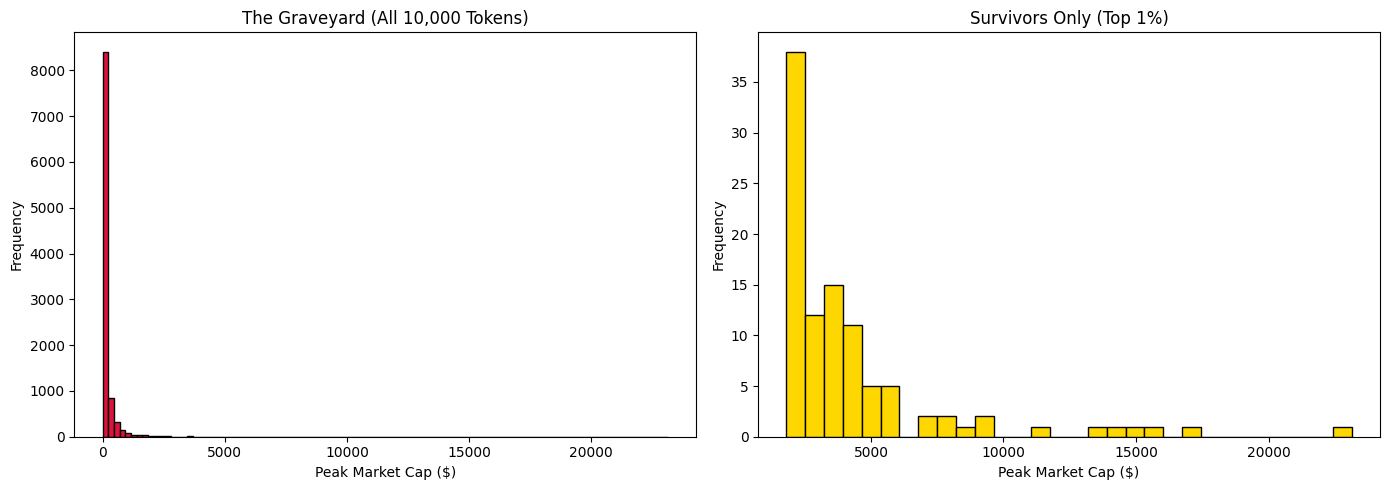

In [13]:
# AI expansion

import matplotlib.pyplot as plt

# Simulate 10,000 token launches using Pareto distribution
np.random.seed(42)
market_caps = np.random.pareto(a=1.5, size=10000) * 100  # scale for readability

# The Graveyard — all tokens
df_all = pd.DataFrame({'Token': [f'Token_{i}' for i in range(10000)],
                        'Peak_Market_Cap': market_caps})

# Survivors — Top 1% only
threshold = np.percentile(market_caps, 99)
df_survivors = df_all[df_all['Peak_Market_Cap'] >= threshold]

# Print the bias
print(f"Mean Market Cap (All 10,000 tokens — The Graveyard): ${np.mean(df_all['Peak_Market_Cap']):.2f}")
print(f"Mean Market Cap (Top 1% — Survivors Only):           ${np.mean(df_survivors['Peak_Market_Cap']):.2f}")
print(f"\nSurvivorship Bias inflates the mean by {np.mean(df_survivors['Peak_Market_Cap']) / np.mean(df_all['Peak_Market_Cap']):.1f}x")

# Dual Histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_all['Peak_Market_Cap'], bins=100, color='crimson', edgecolor='black')
axes[0].set_title('The Graveyard (All 10,000 Tokens)')
axes[0].set_xlabel('Peak Market Cap ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_survivors['Peak_Market_Cap'], bins=30, color='gold', edgecolor='black')
axes[1].set_title('Survivors Only (Top 1%)')
axes[1].set_xlabel('Peak Market Cap ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()